# Store heterogeneity in sales, assortment, and calendar

The main question of this notebook is: **How unequal are stores overall?** Store sales are therefore pooled across all four sourcing groups before the Lorenz curve and Gini coefficient are calculated. Group-level demand concentration is not used to answer the main question.

The remaining sections investigate possible dimensions of this overall heterogeneity:

1. How unequal are total sales and active-series counts across stores?
2. Is the 278-product Pseudo meat range carried broadly or store-specifically?
3. How much does demand density differ by store after accounting for product effects?
4. How widely do weekday profiles vary across stores, especially the Pseudo Saturday factor?
5. Is pre-holiday demand uplift uniform across stores, and do subsequent closure counts differ?

All store analyses use a common eligibility rule: a store must have at least 10 active product-store series in the period shared by all four sourcing groups. The number and identities of excluded stores are reported before the analysis.

The results are descriptive. In particular, `is_active` is **not a historical listing indicator**: the daily grid begins with a product-store pair's first positive sale and continues to the end of the dataset. An observed pair therefore establishes that the combination was sold during the data history, not that the product remained formally listed on every subsequent day.

In [ ]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/ba-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display

PROJECT_ROOT_CANDIDATES = [Path("../.."), Path(".")]
PROJECT_ROOT = next(
    (path.resolve() for path in PROJECT_ROOT_CANDIDATES if (path / "data").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project data directory not found.")

DATA_DIR = PROJECT_ROOT / "data/processed/transactions"
DATA_GLOB = str(DATA_DIR / "*.parquet")
if not any(DATA_DIR.glob("*.parquet")):
    raise FileNotFoundError(f"Processed transaction files not found in {DATA_DIR}")

RECENT_START = pd.Timestamp("2025-04-14")
EVENT_DATES = pd.to_datetime(["2026-04-30", "2026-05-22", "2026-05-23"])
MIN_DENSITY_ACTIVE_DAYS = 60
MIN_WEEKDAY_ACTIVE_DAYS = 30
MIN_WEEKDAY_DEMAND_DAYS = 10
MIN_WEEKDAY_PRODUCTS = 1
MIN_STORE_ACTIVE_SERIES = 10

GROUP_ORDER = ["FCM Fleisch", "FCM Wurst", "Pseudo Fleisch", "Pseudo Wurst"]
GROUP_LABELS_EN = {
    "FCM Fleisch": "FCM meat", "FCM Wurst": "FCM sausage",
    "Pseudo Fleisch": "Pseudo meat", "Pseudo Wurst": "Pseudo sausage",
}
GROUP_COLORS = {
    "FCM Fleisch": "#E76F51",
    "FCM Wurst": "#D1495B",
    "Pseudo Fleisch": "#2A9D8F",
    "Pseudo Wurst": "#457B9D",
}
SOURCE_COLORS = {"FCM": "#D45D45", "Pseudo": "#E3A83B"}
WEEKDAY_LABELS = {1: "Mo", 2: "Di", 3: "Mi", 4: "Do", 5: "Fr", 6: "Sa", 7: "So"}
EVENT_LABELS_EN = {
    pd.Timestamp("2026-04-30"): "30 April (before 1 May)",
    pd.Timestamp("2026-05-22"): "22 May (Friday before Pentecost)",
    pd.Timestamp("2026-05-23"): "23 May (Saturday before Pentecost)",
}
EVENT_LABELS_DE = {
    pd.Timestamp("2026-04-30"): "30.04. (vor 1. Mai)",
    pd.Timestamp("2026-05-22"): "22.05. (Fr vor Pfingsten)",
    pd.Timestamp("2026-05-23"): "23.05. (Sa vor Pfingsten)",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 30)
con = duckdb.connect()
con.execute("PRAGMA threads=4")

## 1. Data population, common period, and store eligibility

The four sourcing groups have different history lengths. Overall store size and concentration are therefore measured only in the date range observed for all four groups. The eligibility rule is also defined in this common period: a store is retained if at least 10 distinct product-store series are active after pooling the groups.

The same eligible-store population is used in all subsequent sections. Assortment breadth still uses the full transaction history, while demand-density and weekday analyses use the recent period beginning on 14 April 2025.

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW transactions AS
SELECT
    *,
    DATE::DATE AS sale_date,
    CASE WHEN is_fcm THEN 'FCM' ELSE 'Pseudo' END AS source_class,
    CASE
        WHEN is_fcm AND WGR_ID = 890 THEN 'FCM Fleisch'
        WHEN is_fcm AND WGR_ID = 900 THEN 'FCM Wurst'
        WHEN is_pseudo AND WGR_ID = 890 THEN 'Pseudo Fleisch'
        WHEN is_pseudo AND WGR_ID = 900 THEN 'Pseudo Wurst'
    END AS source_group
FROM read_parquet('{DATA_GLOB}')
WHERE WGR_ID IN (890, 900)
  AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
""")

coverage = con.execute("""
SELECT
    source_group,
    MIN(sale_date) FILTER (WHERE is_active) AS first_date,
    MAX(sale_date) FILTER (WHERE is_active) AS last_date,
    COUNT(DISTINCT ARTIKEL_ID) FILTER (WHERE ABVERKAUFTE_MENGE_KG > 0) AS products,
    COUNT(DISTINCT MARKT_ID) FILTER (WHERE is_active) AS stores,
    SUM(ABVERKAUFTE_MENGE_KG) FILTER (WHERE is_active) AS total_kg
FROM transactions
GROUP BY source_group
ORDER BY source_group
""").fetchdf()
coverage["source_group"] = pd.Categorical(
    coverage.source_group, GROUP_ORDER, ordered=True
)
coverage = coverage.sort_values("source_group").reset_index(drop=True)
common_start = pd.Timestamp(coverage.first_date.max())
common_end = pd.Timestamp(coverage.last_date.min())

con.execute(f"""
CREATE OR REPLACE TEMP TABLE store_eligibility AS
WITH store_counts AS (
    SELECT
        MARKT_ID AS store_id,
        COUNT(DISTINCT ARTIKEL_ID) FILTER (WHERE is_active) AS active_series,
        SUM(ABVERKAUFTE_MENGE_KG) FILTER (WHERE is_active) AS total_kg
    FROM transactions
    WHERE sale_date BETWEEN DATE '{common_start:%Y-%m-%d}'
                            AND DATE '{common_end:%Y-%m-%d}'
    GROUP BY MARKT_ID
)
SELECT
    *,
    active_series >= {MIN_STORE_ACTIVE_SERIES} AS eligible
FROM store_counts
""")
store_eligibility = con.execute(
    "SELECT * FROM store_eligibility ORDER BY active_series, store_id"
).fetchdf()
eligible_store_count = int(store_eligibility.eligible.sum())
filtered_store_count = int((~store_eligibility.eligible).sum())
filtered_stores = store_eligibility.loc[
    ~store_eligibility.eligible, ["store_id", "active_series", "total_kg"]
].reset_index(drop=True)

coverage_display = coverage.copy()
coverage_display["source_group"] = coverage_display.source_group.astype(str).map(GROUP_LABELS_EN)
display(coverage_display.rename(columns={"source_group": "sourcing_group"}))
display(Markdown(
    f"**Common period:** {common_start:%d %B %Y} to {common_end:%d %B %Y}."
))
display(pd.DataFrame({
    "metric": [
        "Stores before eligibility filter",
        f"Stores with at least {MIN_STORE_ACTIVE_SERIES} active series",
        "Stores excluded",
    ],
    "value": [len(store_eligibility), eligible_store_count, filtered_store_count],
}))
display(Markdown(f"**Excluded stores ({filtered_store_count}):**"))
display(filtered_stores.style.format({"total_kg": "{:,.1f}"}))

,sourcing_group,first_date,last_date,products,stores,total_kg
0,FCM meat,2025-09-16,2026-07-21,9,149,1.707146e+04
1,FCM sausage,2025-04-17,2026-07-21,20,190,1.630467e+05
2,Pseudo meat,2023-07-22,2026-07-21,279,192,2.200422e+07
3,Pseudo sausage,2023-07-22,2026-07-21,18,155,9.669152e+03


**Common period:** 16 September 2025 to 21 July 2026.

,metric,value
0,Stores before eligibility filter,192
1,Stores with at least 10 active series,191
2,Stores excluded,1


**Excluded stores (1):**

,store_id,active_series,total_kg
0,1350068,1,16.1


## 2. Overall store size and sales concentration

The Lorenz curve and Gini coefficient are calculated from **total store sales pooled across all four sourcing groups** in the common period. Each eligible store appears exactly once. `total_kg` is its complete sales volume, while `active_series` is the number of distinct active product-store series across the pooled population.

The Lorenz curve orders stores from the smallest to the largest sales volume. Greater distance below the equality line indicates stronger inequality. The table additionally reports the sales share carried by the largest 10% of eligible stores.

,eligible_stores,total_kg,median_kg_per_store,median_active_series,gini_kg,top_10pct_store_count,top_10pct_store_kg_share
0,191,"5,971,777","24,871.3",115,0.345,20,24.8%


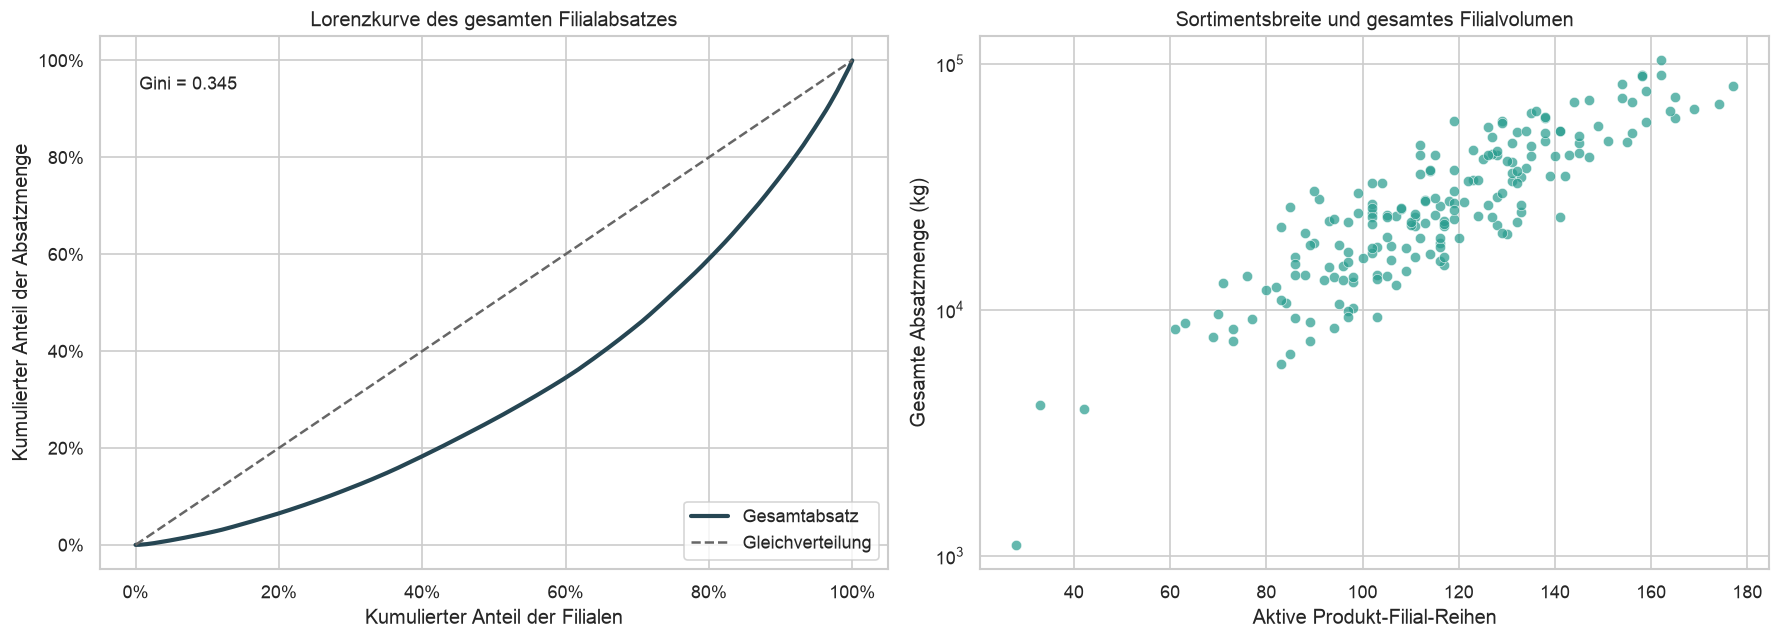

In [3]:
store_size = con.execute(f"""
SELECT
    t.MARKT_ID AS store_id,
    SUM(t.ABVERKAUFTE_MENGE_KG) AS total_kg,
    COUNT(DISTINCT t.ARTIKEL_ID) AS active_series
FROM transactions t
JOIN store_eligibility e ON e.store_id = t.MARKT_ID
WHERE t.is_active
  AND e.eligible
  AND t.sale_date BETWEEN DATE '{common_start:%Y-%m-%d}'
                      AND DATE '{common_end:%Y-%m-%d}'
GROUP BY t.MARKT_ID
""").fetchdf()

def gini(values):
    values = np.sort(np.asarray(values, dtype=float))
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    ranks = np.arange(1, len(values) + 1)
    return 2 * np.sum(ranks * values) / (len(values) * values.sum()) - (len(values) + 1) / len(values)

descending = store_size.total_kg.sort_values(ascending=False)
top_count = max(1, int(np.ceil(0.10 * len(store_size))))
overall_concentration = {
    "eligible_stores": len(store_size),
    "total_kg": store_size.total_kg.sum(),
    "median_kg_per_store": store_size.total_kg.median(),
    "median_active_series": store_size.active_series.median(),
    "gini_kg": gini(store_size.total_kg),
    "top_10pct_store_count": top_count,
    "top_10pct_store_kg_share": descending.iloc[:top_count].sum() / descending.sum(),
}
concentration = pd.DataFrame([overall_concentration])

ascending = np.sort(store_size.total_kg.to_numpy(dtype=float))
lorenz = pd.DataFrame({
    "cumulative_stores": np.linspace(0, 1, len(ascending) + 1),
    "cumulative_kg": np.r_[0, np.cumsum(ascending) / ascending.sum()],
})
display(concentration.style.format({
    "total_kg": "{:,.0f}", "median_kg_per_store": "{:,.1f}",
    "median_active_series": "{:.0f}", "gini_kg": "{:.3f}",
    "top_10pct_store_kg_share": "{:.1%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(
    lorenz.cumulative_stores, lorenz.cumulative_kg,
    linewidth=2.5, color="#264653", label="Gesamtabsatz",
)
axes[0].plot([0, 1], [0, 1], color="0.4", linestyle="--", label="Gleichverteilung")
axes[0].text(
    0.05, 0.90, f"Gini = {overall_concentration['gini_kg']:.3f}",
    transform=axes[0].transAxes, fontsize=11,
)
axes[0].set_xlabel("Kumulierter Anteil der Filialen")
axes[0].set_ylabel("Kumulierter Anteil der Absatzmenge")
axes[0].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].set_title("Lorenzkurve des gesamten Filialabsatzes")
axes[0].legend()

axes[1].scatter(
    store_size.active_series, store_size.total_kg,
    alpha=0.72, s=38, color="#2A9D8F", edgecolor="white", linewidth=0.4,
)
axes[1].set_yscale("log")
axes[1].set_xlabel("Aktive Produkt-Filial-Reihen")
axes[1].set_ylabel("Gesamte Absatzmenge (kg)")
axes[1].set_title("Sortimentsbreite und gesamtes Filialvolumen")
fig.tight_layout()
plt.show()

## 3. Observed Pseudo meat assortment breadth

The 278 Pseudo meat products form the product universe observed across the eligible stores. `products_per_store` counts products with at least one positive sale in the complete history. Conversely, `stores_per_product` counts the eligible stores in which a product records at least one positive sale. These measures describe observed reach rather than date-specific formal listings.

,metric,value
0,Pseudo meat products in the observed universe,279.0
1,Eligible stores with Pseudo meat sales,191.0
2,Median products per store,96.0
3,Maximum products per store,155.0
4,Products observed in every eligible store,6.0
5,Median stores per product,27.0


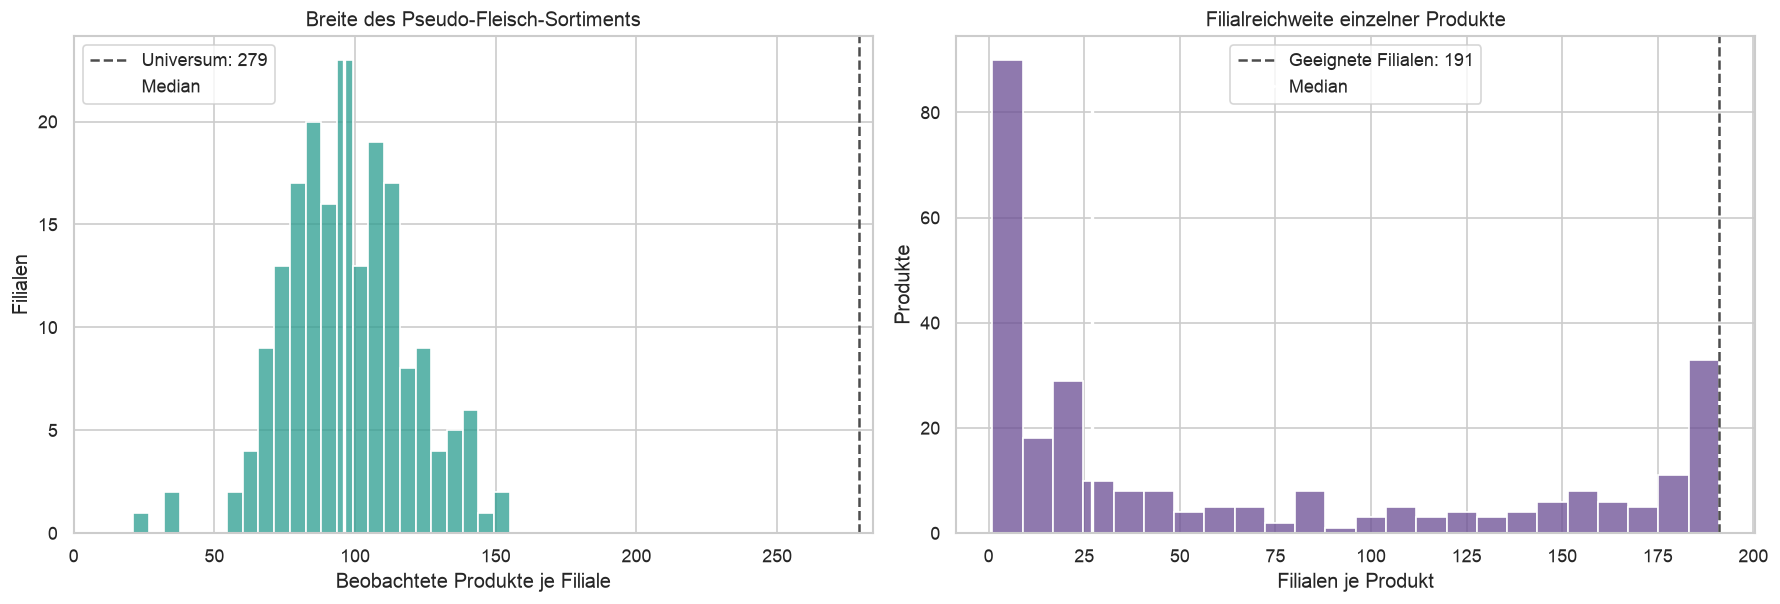

In [4]:
pseudo_breadth = con.execute("""
SELECT
    t.MARKT_ID AS store_id,
    COUNT(DISTINCT t.ARTIKEL_ID) AS products_per_store
FROM transactions t
JOIN store_eligibility e ON e.store_id = t.MARKT_ID
WHERE t.source_group = 'Pseudo Fleisch'
  AND t.ABVERKAUFTE_MENGE_KG > 0
  AND e.eligible
GROUP BY t.MARKT_ID
""").fetchdf()

pseudo_reach = con.execute("""
SELECT
    t.ARTIKEL_ID AS article_id,
    COUNT(DISTINCT t.MARKT_ID) AS stores_per_product
FROM transactions t
JOIN store_eligibility e ON e.store_id = t.MARKT_ID
WHERE t.source_group = 'Pseudo Fleisch'
  AND t.ABVERKAUFTE_MENGE_KG > 0
  AND e.eligible
GROUP BY t.ARTIKEL_ID
""").fetchdf()

pseudo_universe = pseudo_reach.article_id.nunique()
pseudo_store_count = pseudo_breadth.store_id.nunique()
breadth_summary = pd.DataFrame({
    "metric": [
        "Pseudo meat products in the observed universe",
        "Eligible stores with Pseudo meat sales",
        "Median products per store",
        "Maximum products per store",
        "Products observed in every eligible store",
        "Median stores per product",
    ],
    "value": [
        pseudo_universe,
        pseudo_store_count,
        pseudo_breadth.products_per_store.median(),
        pseudo_breadth.products_per_store.max(),
        (pseudo_reach.stores_per_product == pseudo_store_count).sum(),
        pseudo_reach.stores_per_product.median(),
    ],
})
display(breadth_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.histplot(
    pseudo_breadth, x="products_per_store", bins=24,
    color=GROUP_COLORS["Pseudo Fleisch"], ax=axes[0],
)
axes[0].axvline(pseudo_universe, color="0.3", linestyle="--", label=f"Universum: {pseudo_universe}")
axes[0].axvline(pseudo_breadth.products_per_store.median(), color="white", linewidth=2, label="Median")
axes[0].set_xlim(0, pseudo_universe + 5)
axes[0].set_xlabel("Beobachtete Produkte je Filiale")
axes[0].set_ylabel("Filialen")
axes[0].set_title("Breite des Pseudo-Fleisch-Sortiments")
axes[0].legend()

sns.histplot(
    pseudo_reach, x="stores_per_product", bins=24,
    color="#6A4C93", ax=axes[1],
)
axes[1].axvline(pseudo_store_count, color="0.3", linestyle="--", label=f"Geeignete Filialen: {pseudo_store_count}")
axes[1].axvline(pseudo_reach.stores_per_product.median(), color="white", linewidth=2, label="Median")
axes[1].set_xlabel("Filialen je Produkt")
axes[1].set_ylabel("Produkte")
axes[1].set_title("Filialreichweite einzelner Produkte")
axes[1].legend()
fig.tight_layout()
plt.show()

## 4. Demand density: product or store effect?

The demand density of a product-store series is the share of active days with positive sales. The analysis retains series with at least 60 active days since 14 April 2025 and includes only stores passing the common eligibility rule. Three descriptive fixed-effects models compare the variance associated with product identifiers, store identifiers, or both. The partial store contribution measures how much of the variance remaining after product fixed effects is additionally explained by `MARKT_ID`.

The OLS diagnostics address three complementary questions: How much does the store identifier improve model fit, how closely do observed and fitted demand densities align, and do residuals vary systematically over the fitted range? Because the response is bounded between zero and one, the share of OLS predictions outside this interval is also reported.

These are in-sample descriptive models, not a causal variance decomposition or forecasting validation.

**Does a product sell frequently because it is inherently frequently demanded, or because it is offered in a store with generally denser demand?**

,model,r_squared,adjusted_r_squared
0,Product FE only,0.650,0.645
1,Store FE only,0.028,0.020
2,Product and store FE,0.716,0.709


,partial_measure,partial_r_squared
0,Store in addition to product,18.8%
1,Product in addition to store,70.8%


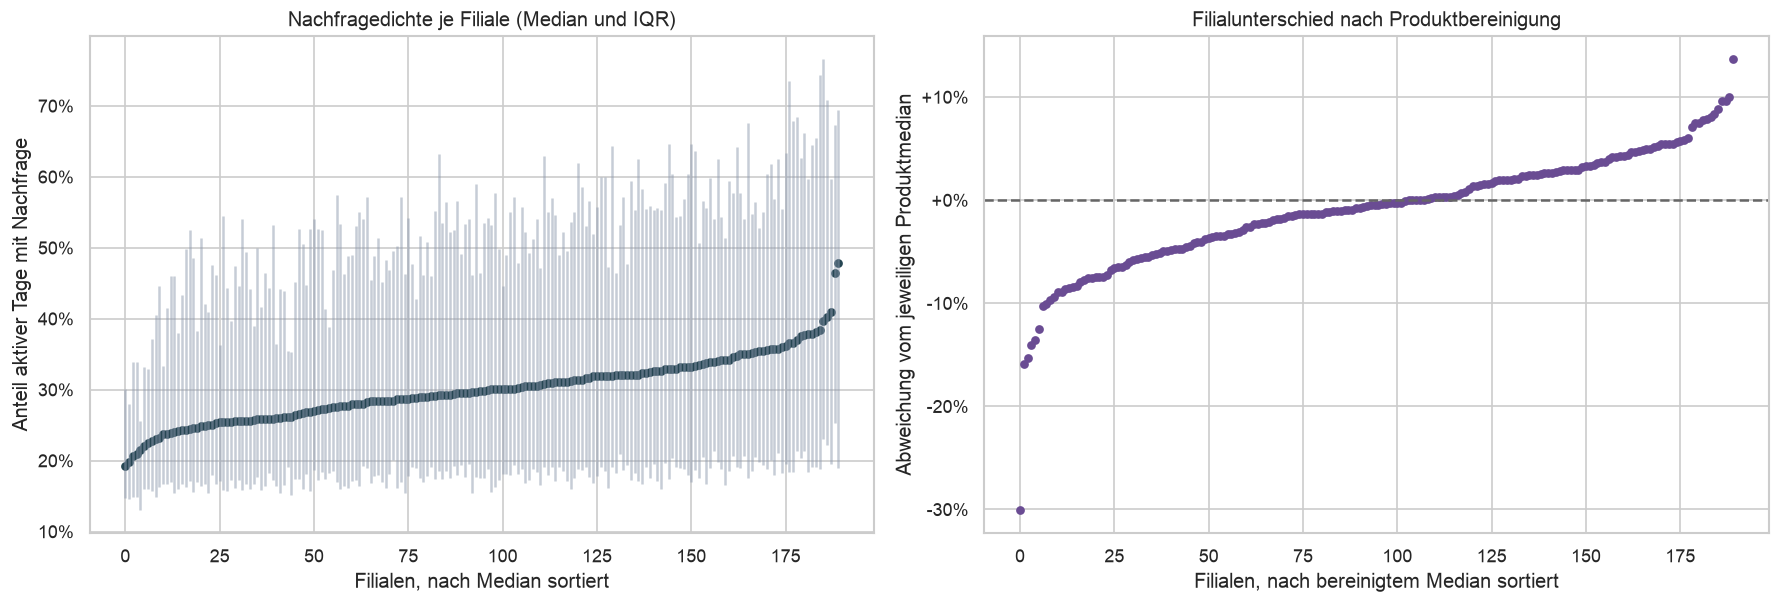

,diagnostic,value
0,RMSE,0.131
1,MAE,0.096
2,"Predictions outside [0, 1]",0.9%


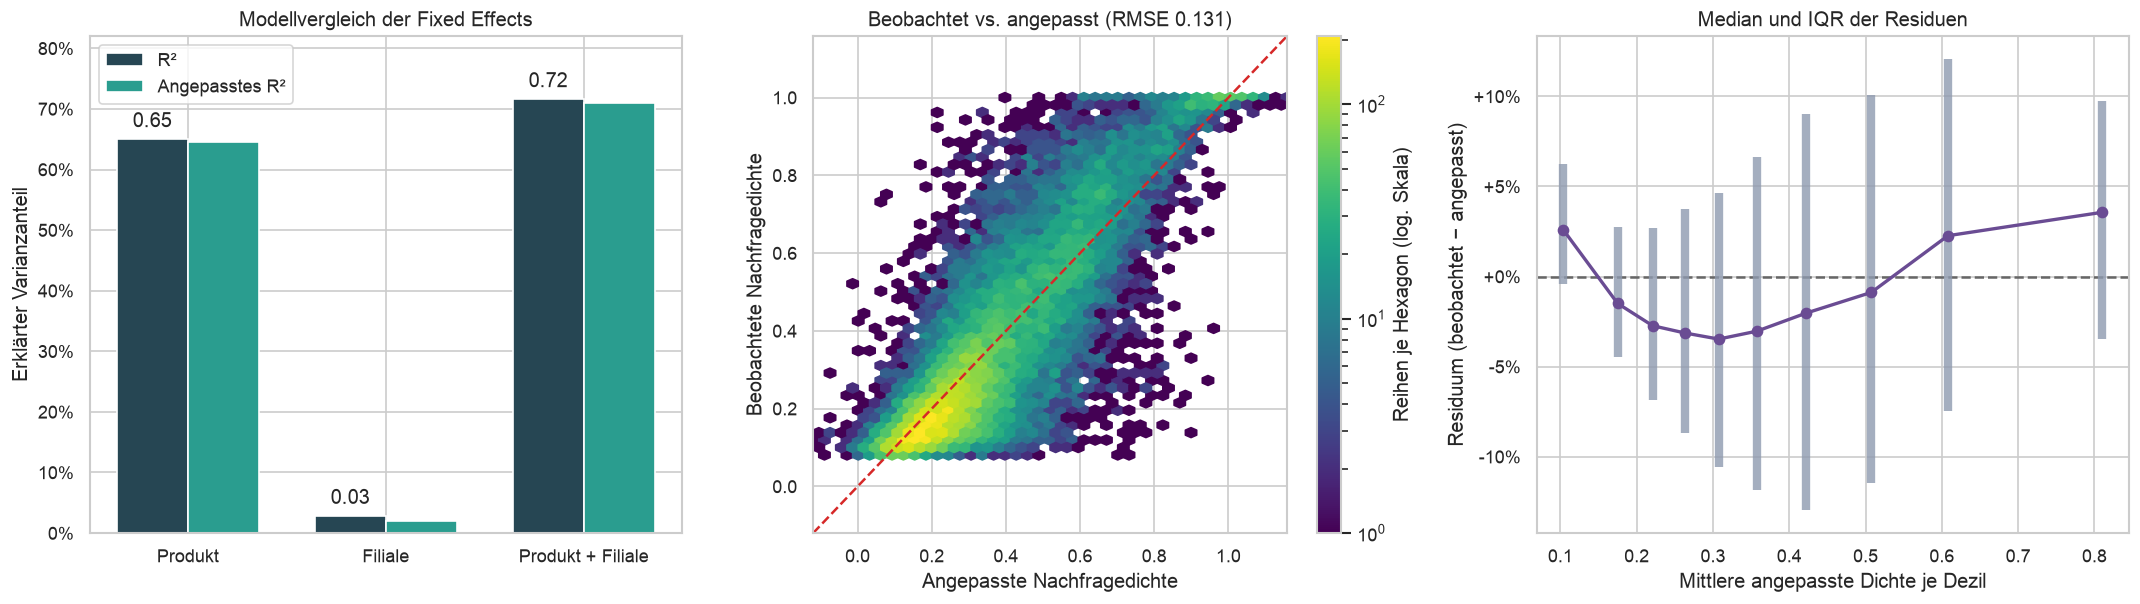

In [9]:
series_density = con.execute(f"""
SELECT
    ARTIKEL_ID AS article_id,
    MARKT_ID AS store_id,
    COUNT(*) AS active_days,
    COUNT_IF(ABVERKAUFTE_MENGE_KG > 0) AS demand_days,
    COUNT_IF(ABVERKAUFTE_MENGE_KG > 0)::DOUBLE / COUNT(*) AS demand_day_ratio
FROM transactions t
JOIN store_eligibility e ON e.store_id = t.MARKT_ID
WHERE t.is_active
  AND e.eligible
  AND t.sale_date >= DATE '{RECENT_START:%Y-%m-%d}'
GROUP BY ARTIKEL_ID, MARKT_ID
HAVING COUNT(*) >= {MIN_DENSITY_ACTIVE_DAYS}
""").fetchdf()

product_medians = series_density.groupby("article_id").demand_day_ratio.median()
series_density["product_adjusted_ratio"] = (
    series_density.demand_day_ratio
    - series_density.article_id.map(product_medians)
)
store_density = (
    series_density.groupby("store_id", as_index=False)
    .agg(
        series=("article_id", "size"),
        q25_ratio=("demand_day_ratio", lambda x: x.quantile(0.25)),
        median_ratio=("demand_day_ratio", "median"),
        q75_ratio=("demand_day_ratio", lambda x: x.quantile(0.75)),
        product_adjusted_median=("product_adjusted_ratio", "median"),
    )
)

model_frame = series_density[["article_id", "store_id", "demand_day_ratio"]].copy()
model_frame["article_id"] = model_frame.article_id.astype(str)
model_frame["store_id"] = model_frame.store_id.astype(str)
model_specs = {
    "Product FE only": "demand_day_ratio ~ C(article_id)",
    "Store FE only": "demand_day_ratio ~ C(store_id)",
    "Product and store FE": "demand_day_ratio ~ C(article_id) + C(store_id)",
}
fits = {name: smf.ols(formula, data=model_frame).fit() for name, formula in model_specs.items()}
density_models = pd.DataFrame([
    {
        "model": name,
        "r_squared": fit.rsquared,
        "adjusted_r_squared": fit.rsquared_adj,
    }
    for name, fit in fits.items()
])
r2_product = fits["Product FE only"].rsquared
r2_store = fits["Store FE only"].rsquared
r2_both = fits["Product and store FE"].rsquared
partial_store_r2 = (r2_both - r2_product) / (1 - r2_product)
partial_product_r2 = (r2_both - r2_store) / (1 - r2_store)

display(density_models.style.format({"r_squared": "{:.3f}", "adjusted_r_squared": "{:.3f}"}))
display(pd.DataFrame({
    "partial_measure": [
        "Store in addition to product",
        "Product in addition to store",
    ],
    "partial_r_squared": [partial_store_r2, partial_product_r2],
}).style.format({"partial_r_squared": "{:.1%}"}))

ordered_raw = store_density.sort_values("median_ratio").reset_index(drop=True)
ordered_adjusted = store_density.sort_values("product_adjusted_median").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
x = np.arange(len(ordered_raw))
axes[0].vlines(x, ordered_raw.q25_ratio, ordered_raw.q75_ratio, color="#8E9AAF", alpha=0.5)
axes[0].scatter(x, ordered_raw.median_ratio, s=18, color="#264653")
axes[0].set_xlabel("Filialen, nach Median sortiert")
axes[0].set_ylabel("Anteil aktiver Tage mit Nachfrage")
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[0].set_title("Nachfragedichte je Filiale (Median und IQR)")

x = np.arange(len(ordered_adjusted))
axes[1].axhline(0, color="0.4", linestyle="--")
axes[1].scatter(x, ordered_adjusted.product_adjusted_median, s=18, color="#6A4C93")
axes[1].set_xlabel("Filialen, nach bereinigtem Median sortiert")
axes[1].set_ylabel("Abweichung vom jeweiligen Produktmedian")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:+.0%}")
axes[1].set_title("Filialunterschied nach Produktbereinigung")
fig.tight_layout()
plt.show()

# OLS model comparison and diagnostics for the combined fixed-effects model.
full_fit = fits["Product and store FE"]
model_frame["fitted_density"] = full_fit.fittedvalues
model_frame["residual"] = full_fit.resid
rmse = np.sqrt(np.mean(model_frame.residual ** 2))
mae = np.mean(np.abs(model_frame.residual))
outside_unit_interval = (~model_frame.fitted_density.between(0, 1)).mean()
display(pd.DataFrame({
    "diagnostic": ["RMSE", "MAE", "Predictions outside [0, 1]"],
    "value": [f"{rmse:.3f}", f"{mae:.3f}", f"{outside_unit_interval:.1%}"],
}))

model_labels = ["Produkt", "Filiale", "Produkt + Filiale"]
model_positions = np.arange(len(density_models))
residual_bins = (
    model_frame.assign(
        fitted_decile=pd.qcut(
            model_frame.fitted_density, q=10, labels=False, duplicates="drop"
        )
    )
    .groupby("fitted_decile", as_index=False)
    .agg(
        mean_fitted=("fitted_density", "mean"),
        q25_residual=("residual", lambda x: x.quantile(0.25)),
        median_residual=("residual", "median"),
        q75_residual=("residual", lambda x: x.quantile(0.75)),
        series=("residual", "size"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
bar_width = 0.36
axes[0].bar(
    model_positions - bar_width / 2, density_models.r_squared,
    width=bar_width, color="#264653", label="R²",
)
axes[0].bar(
    model_positions + bar_width / 2, density_models.adjusted_r_squared,
    width=bar_width, color="#2A9D8F", label="Angepasstes R²",
)
for position, value in zip(model_positions, density_models.r_squared):
    axes[0].text(position - bar_width / 2, value + 0.02, f"{value:.2f}", ha="center")
axes[0].set_xticks(model_positions, model_labels)
axes[0].set_ylim(0, 0.82)
axes[0].set_ylabel("Erklärter Varianzanteil")
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[0].set_title("Modellvergleich der Fixed Effects")
axes[0].legend()

hexbin = axes[1].hexbin(
    model_frame.fitted_density, model_frame.demand_day_ratio,
    gridsize=42, mincnt=1, bins="log", cmap="viridis",
)
comparison_min = min(0, model_frame.fitted_density.min())
comparison_max = max(1, model_frame.fitted_density.max())
axes[1].plot(
    [comparison_min, comparison_max], [comparison_min, comparison_max],
    color="#D62828", linestyle="--", linewidth=1.5,
)
axes[1].set_xlim(comparison_min, comparison_max)
axes[1].set_ylim(comparison_min, comparison_max)
axes[1].set_xlabel("Angepasste Nachfragedichte")
axes[1].set_ylabel("Beobachtete Nachfragedichte")
axes[1].set_title(f"Beobachtet vs. angepasst (RMSE {rmse:.3f})")
fig.colorbar(hexbin, ax=axes[1], label="Reihen je Hexagon (log. Skala)")

axes[2].axhline(0, color="0.4", linestyle="--")
axes[2].vlines(
    residual_bins.mean_fitted, residual_bins.q25_residual,
    residual_bins.q75_residual, color="#8E9AAF", linewidth=5, alpha=0.8,
)
axes[2].plot(
    residual_bins.mean_fitted, residual_bins.median_residual,
    marker="o", color="#6A4C93", linewidth=2,
)
axes[2].set_xlabel("Mittlere angepasste Dichte je Dezil")
axes[2].set_ylabel("Residuum (beobachtet − angepasst)")
axes[2].yaxis.set_major_formatter(lambda value, _: f"{value:+.0%}")
axes[2].set_title("Median und IQR der Residuen")
fig.tight_layout()
plt.show()

## 5. Store-level weekday shape

The normalization matches the weekday-seasonality notebook: daily demand is divided by the mean of the active Monday-to-Saturday days within each product-store-week. A factor of 1.60 therefore represents demand 60% above the mean of the same product-store-week. A store's Saturday factor is the mean of all normalized Saturday observations from its eligible series. At least one eligible product must contribute so that all four sourcing groups can be compared. Because the thinner groups may be represented by fewer products per store, the summary table also reports the median number of contributing products. All Sundays are inactive and therefore excluded from the weekday-shape analysis.


In [ ]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE weekday_daily AS
SELECT
    ARTIKEL_ID AS article_id,
    MARKT_ID AS store_id,
    source_group,
    sale_date,
    DATE_TRUNC('week', sale_date)::DATE AS week_date,
    ISODOW(sale_date) AS weekday,
    SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM transactions
WHERE is_active
  AND MARKT_ID IN (SELECT store_id FROM store_eligibility WHERE eligible)
  AND sale_date >= DATE '{RECENT_START:%Y-%m-%d}'
  AND ISODOW(sale_date) BETWEEN 1 AND 6
GROUP BY ARTIKEL_ID, MARKT_ID, source_group, sale_date,
         DATE_TRUNC('week', sale_date), ISODOW(sale_date)
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE weekday_normalized AS
WITH eligible_series AS (
    SELECT article_id, source_group, store_id
    FROM weekday_daily
    GROUP BY article_id, source_group, store_id
    HAVING COUNT(*) >= {MIN_WEEKDAY_ACTIVE_DAYS}
       AND COUNT_IF(demand_kg > 0) >= {MIN_WEEKDAY_DEMAND_DAYS}
), eligible_weeks AS (
    SELECT
        d.article_id, d.source_group, d.store_id, d.week_date,
        AVG(d.demand_kg) AS mean_daily_demand
    FROM weekday_daily d
    JOIN eligible_series e USING (article_id, source_group, store_id)
    GROUP BY d.article_id, d.source_group, d.store_id, d.week_date
    HAVING COUNT(*) >= 5 AND SUM(demand_kg) > 0
)
SELECT
    d.*,
    d.demand_kg / NULLIF(w.mean_daily_demand, 0) AS normalized_demand
FROM weekday_daily d
JOIN eligible_weeks w USING (article_id, source_group, store_id, week_date)
""")

store_weekday_factors = con.execute("""
SELECT
    source_group,
    store_id,
    weekday,
    AVG(normalized_demand) AS weekday_factor,
    COUNT(DISTINCT article_id) AS products
FROM weekday_normalized
GROUP BY source_group, store_id, weekday
""").fetchdf()
saturday_factors = store_weekday_factors[
    (store_weekday_factors.weekday == 6)
    & (store_weekday_factors.products >= MIN_WEEKDAY_PRODUCTS)
].copy()

saturday_summary = (
    saturday_factors.groupby("source_group", as_index=False)
    .agg(
        stores=("store_id", "size"),
        median_products=("products", "median"),
        q10=("weekday_factor", lambda x: x.quantile(0.10)),
        q25=("weekday_factor", lambda x: x.quantile(0.25)),
        median=("weekday_factor", "median"),
        q75=("weekday_factor", lambda x: x.quantile(0.75)),
        q90=("weekday_factor", lambda x: x.quantile(0.90)),
    )
)
saturday_summary_display = saturday_summary.copy()
saturday_summary_display["source_group"] = (
    saturday_summary_display.source_group.map(GROUP_LABELS_EN)
)
display(saturday_summary_display.style.format({
    "median_products": "{:.0f}",
    "q10": "{:.2f}", "q25": "{:.2f}", "median": "{:.2f}",
    "q75": "{:.2f}", "q90": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(10, 5.4))
sns.boxplot(
    data=saturday_factors, x="source_group", y="weekday_factor",
    hue="source_group", order=GROUP_ORDER, palette=GROUP_COLORS,
    width=0.45, showfliers=False, legend=False, ax=ax,
)
sns.stripplot(
    data=saturday_factors, x="source_group", y="weekday_factor",
    order=GROUP_ORDER, color="0.25", alpha=0.35, size=3, ax=ax,
)
ax.axhline(1, color="0.4", linestyle="--")
ax.set_xlabel("Quellgruppe")
ax.set_ylabel("Samstagsfaktor")
ax.set_title("Streuung des Samstagsfaktors zwischen Filialen")
ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
plt.show()


## 6. Pre-holiday behavior and store-specific closures

For 30 April and 22–23 May 2026, each eligible store's kilograms per active product series are compared with its median for the same weekday within ±56 days. At least six baseline days are required. This factor approximately controls for store size, active assortment breadth, weekday, and local season, but remains descriptive rather than causal.

A store calendar is also constructed exactly as in the feature builder: a store-day is closed when none of its series is active. `closed_next_3` counts closed days in the following three calendar days and reveals whether a global calendar would carry the same information.

In [ ]:
store_daily = con.execute(f"""
SELECT
    MARKT_ID AS store_id,
    sale_date,
    SUM(ABVERKAUFTE_MENGE_KG) AS total_kg,
    COUNT(DISTINCT ARTIKEL_ID) AS active_series,
    SUM(ABVERKAUFTE_MENGE_KG) / COUNT(DISTINCT ARTIKEL_ID) AS kg_per_active_series
FROM transactions
WHERE is_active
  AND MARKT_ID IN (SELECT store_id FROM store_eligibility WHERE eligible)
  AND sale_date >= DATE '{RECENT_START:%Y-%m-%d}'
GROUP BY MARKT_ID, sale_date
""").fetchdf()
store_daily["sale_date"] = pd.to_datetime(store_daily.sale_date)

event_rows = []
for event_date in EVENT_DATES:
    weekday = event_date.dayofweek
    baseline = store_daily[
        (store_daily.sale_date.sub(event_date).abs().dt.days <= 56)
        & (store_daily.sale_date.dt.dayofweek == weekday)
        & (~store_daily.sale_date.isin(EVENT_DATES))
    ]
    baseline_store = (
        baseline.groupby("store_id").kg_per_active_series
        .agg(baseline_median="median", baseline_days="size")
        .reset_index()
    )
    event = store_daily[store_daily.sale_date == event_date].merge(
        baseline_store, on="store_id", how="inner", validate="one_to_one"
    )
    event = event[event.baseline_days >= 6].copy()
    event["event_date"] = event_date
    event["lift_factor"] = event.kg_per_active_series / event.baseline_median
    event_rows.append(event)

preholiday_lift = pd.concat(event_rows, ignore_index=True)
preholiday_lift["event_label"] = preholiday_lift.event_date.map(EVENT_LABELS_EN)
lift_summary = (
    preholiday_lift.groupby(["event_date", "event_label"], as_index=False)
    .lift_factor.agg(
        stores="size",
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
        share_above_one=lambda x: (x > 1).mean(),
    )
)
display(lift_summary.style.format({
    "q25": "{:.2f}", "median": "{:.2f}", "q75": "{:.2f}",
    "share_above_one": "{:.1%}",
}))

closure_by_store = con.execute("""
WITH store_calendar AS (
    SELECT
        MARKT_ID AS store_id,
        sale_date,
        NOT BOOL_OR(is_active) AS is_closed
    FROM transactions
    WHERE MARKT_ID IN (SELECT store_id FROM store_eligibility WHERE eligible)
    GROUP BY MARKT_ID, sale_date
), events(event_date) AS (
    VALUES (DATE '2026-04-30'), (DATE '2026-05-22'), (DATE '2026-05-23')
), event_stores AS (
    SELECT e.event_date, c.store_id
    FROM events e
    JOIN store_calendar c ON c.sale_date = e.event_date
    WHERE NOT c.is_closed
)
SELECT
    e.event_date,
    e.store_id,
    COALESCE(next_1.is_closed, FALSE)::INTEGER
      + COALESCE(next_2.is_closed, FALSE)::INTEGER
      + COALESCE(next_3.is_closed, FALSE)::INTEGER AS closed_next_3
FROM event_stores e
LEFT JOIN store_calendar next_1
  ON next_1.store_id = e.store_id
 AND next_1.sale_date = e.event_date + INTERVAL 1 DAY
LEFT JOIN store_calendar next_2
  ON next_2.store_id = e.store_id
 AND next_2.sale_date = e.event_date + INTERVAL 2 DAY
LEFT JOIN store_calendar next_3
  ON next_3.store_id = e.store_id
 AND next_3.sale_date = e.event_date + INTERVAL 3 DAY
""").fetchdf()
closure_by_store["event_date"] = pd.to_datetime(closure_by_store.event_date)
closure_summary = (
    closure_by_store.groupby(["event_date", "closed_next_3"], as_index=False)
    .agg(stores=("store_id", "size"))
)
display(closure_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.5, 1]})
preholiday_lift["plot_event_label"] = preholiday_lift.event_date.map(EVENT_LABELS_DE)
event_order = [EVENT_LABELS_DE[date] for date in EVENT_DATES]
sns.boxplot(
    data=preholiday_lift, x="plot_event_label", y="lift_factor",
    order=event_order, color="#E9C46A", showfliers=False, ax=axes[0],
)
sns.stripplot(
    data=preholiday_lift, x="plot_event_label", y="lift_factor",
    order=event_order, color="0.25", alpha=0.28, size=3, ax=axes[0],
)
axes[0].axhline(1, color="0.4", linestyle="--", label="Lokaler Wochentagsmedian")
axes[0].set_xlabel("")
axes[0].set_ylabel("Absatzfaktor je aktiver Reihe")
axes[0].set_title("Vorfeiertagsfaktor je Filiale")
axes[0].tick_params(axis="x", rotation=12)
axes[0].legend(loc="upper right")

closure_plot = closure_summary.copy()
closure_plot["event_label"] = closure_plot.event_date.map(EVENT_LABELS_DE)
closure_pivot = closure_plot.pivot(
    index="event_label", columns="closed_next_3", values="stores"
).fillna(0).reindex(event_order)
closure_pivot.plot(
    kind="bar", stacked=True, color=["#2A9D8F", "#457B9D"], ax=axes[1]
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Filialen")
axes[1].set_title("Geschlossene Tage in den folgenden 3 Tagen")
axes[1].tick_params(axis="x", rotation=12)
axes[1].legend(title="closed_next_3")
fig.tight_layout()
plt.show()

## 7. Automatically derived findings

The following statements are generated directly from the computed tables so that interpretation remains synchronized with the data.

In [ ]:
pseudo_meat_sat = saturday_summary.loc[
    saturday_summary.source_group == "Pseudo Fleisch"
].iloc[0]

lift_text = "\n".join(
    f"- **{row.event_label}:** median {row.median:.2f}, "
    f"IQR {row.q25:.2f}–{row.q75:.2f}; "
    f"{row.share_above_one:.1%} of stores exceed their local baseline."
    for row in lift_summary.itertuples()
)

display(Markdown(f"""
- **Overall store inequality:** After pooling all four groups, the {eligible_store_count} eligible stores have a sales Gini coefficient of {overall_concentration['gini_kg']:.3f}. The largest 10% ({overall_concentration['top_10pct_store_count']} stores) contribute {overall_concentration['top_10pct_store_kg_share']:.1%} of total sales. The Lorenz curve therefore describes inequality between complete stores rather than inequality within sourcing groups.
- **Eligibility filter:** {filtered_store_count} of {len(store_eligibility)} stores were excluded because they had fewer than {MIN_STORE_ACTIVE_SERIES} active series in the common period. All subsequent store-level results use the same eligible population.
- **The 278-product universe is store-specific:** An eligible store carries a median of {pseudo_breadth.products_per_store.median():.0f} observed Pseudo meat products and a maximum of {pseudo_breadth.products_per_store.max():.0f}. No product appears in every one of the {pseudo_store_count} eligible stores. Because historical listing states are unavailable, this is evidence about observed sales reach rather than formal assortment status.
- **Both product and store relate to demand density:** Product fixed effects explain {r2_product:.1%} of in-sample variance. Adding store fixed effects raises explained variance to {r2_both:.1%}; relative to the variance remaining after product effects, the partial store contribution is {partial_store_r2:.1%}. This supports retaining `MARKT_ID` as a separate feature.
- **The Saturday increase is broad but not identical:** The median Pseudo meat Saturday factor across eligible stores is {pseudo_meat_sat['median']:.2f}, with the middle 50% ranging from {pseudo_meat_sat.q25:.2f} to {pseudo_meat_sat.q75:.2f}. Pooling stores therefore masks meaningful amplitude differences.
- **Sunday closure is global:** Every store is inactive on Sundays in the prepared calendar, so Sunday observations do not enter active-day analyses.

**Pre-holiday behavior**

{lift_text}

The uplift direction is therefore nearly universal, while its magnitude remains store-specific. Sundays contribute consistently to the following-three-day closure count for every store; the feature remains calculated by `MARKT_ID` so any other store-specific closure differences are retained.
"""))